In [1]:
# %load_ext autoreload
# %autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots.eis_plot import NyquistPlot
from redoxed.plots.drt_plot import DRTPlot
from redoxed.impedance import EISData, DRTData

import pyDRTtools

%matplotlib inline

Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

In [ ]:
# without cables
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
# with cables
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\16_cables_banana_bigloop_01_GEIS_C02.mpr"

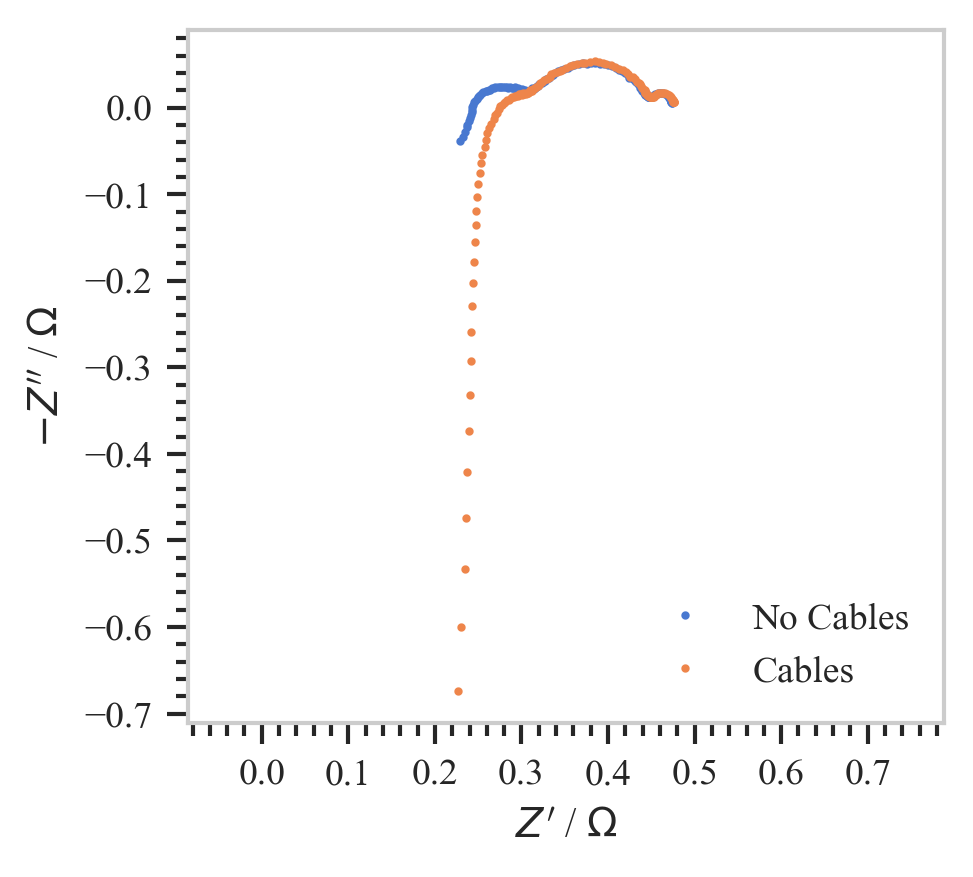

In [57]:
EISData_array = []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "No Cables"
EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\16_cables_banana_bigloop_01_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "Cables"
EISData_array.append(EISData_object)




data_plot = NyquistPlot(figsize=(3.25, 3), dpi=300) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    EISData_object.crop_frequency(0.001, 2e5)
    data_plot.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(major_tick_spacing = 0.1)
data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -1.9357e+01 -2.0894e+01  2e+02  1e+01  6e-05
 1: -1.8631e+01 -2.1804e+01  2e+01  1e+00  5e-06
 2: -1.8926e+01 -2.0694e+01  2e+00  2e-02  9e-08
 3: -1.9100e+01 -2.0681e+01  2e+00  1e-02  5e-08
 4: -1.9316e+01 -1.9542e+01  2e-01  8e-04  4e-09
 5: -1.9355e+01 -1.9386e+01  3e-02  7e-06  3e-11
 6: -1.9359e+01 -1.9362e+01  4e-03  2e-07  8e-13
 7: -1.9359e+01 -1.9360e+01  1e-03  4e-17  5e-16
 8: -1.9359e+01 -1.9360e+01  3e-04  3e-17  1e-16
 9: -1.9359e+01 -1.9359e+01  3e-04  2e-17  8e-17
10: -1.9359e+01 -1.9359e+01  5e-05  3e-17  2e-16
11: -1.9359e+01 -1.9359e+01  2e-05  3e-17  1e-16
12: -1.9359e+01 -1.9359e+01  5e-06  4e-17  5e-16
Optimal solution found.
ed's tau adjustment made
The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -1.8964e+01 -2.0485e+01  2e+02  1e+01  2e-04
 1: -1.8230e+01 -2.1393e+01  2e+01  1e+00  2e-05
 2: -1.8517e+01 -2

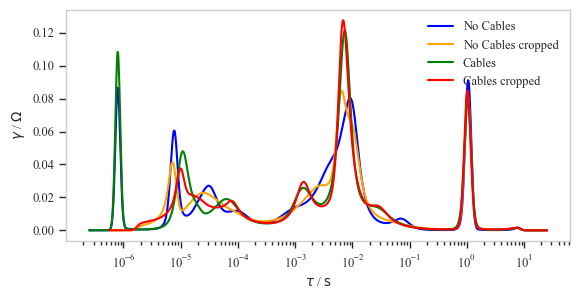

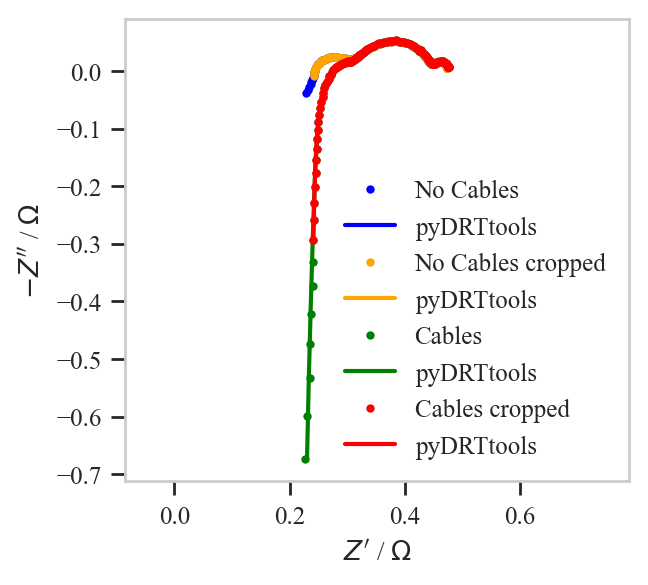

In [63]:
EISData_array = []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "No Cables"
EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "No Cables cropped"
EISData_object.crop_frequency(0.001, 1e5)
EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\16_cables_banana_bigloop_01_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "Cables"
EISData_array.append(EISData_object)

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\16_cables_banana_bigloop_01_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "Cables cropped"
EISData_object.crop_frequency(0.001, 1e5)
EISData_array.append(EISData_object)

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    # EISData_object.crop_frequency(0.001, 2e5)
    pass


DRT_array = []
L_array = []
R_array = []
EIS_fitted_array = []

for i, EISData_object in enumerate(EISData_array):
    # Load measurement data into EIS_object
    pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
    # this includes tau definition of
    # # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
    # # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0])


    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda
    lambda_0 = 1e-9 # initial guess
    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "pyDRTtools")

    DRT_array.append(DRT_object_pyDRTtools)
    L_array.append(L_pyDRTtools)
    R_array.append(R_pyDRTtools)
    EIS_fitted_array.append(EISData_fitted_pyDRTtools)


color_array = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
drt_plot = DRTPlot(figsize=(6.5, 3), dpi=100) 

nyquist_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for i, DRT_object in enumerate(DRT_array): 
    drt_plot.add_plot(DRT_object, linestyle = "-", marker = "", color=color_array[i])
    nyquist_plot.add_plot(EISData_array[i], linestyle = "", marker = "o", markersize = 2, color=color_array[i])
    nyquist_plot.add_plot(EIS_fitted_array[i], linestyle = "-", marker = "", color = color_array[i])
    print(f"DRT for {EISData_array[i].label}:")
    print(f"R = {R_array[i]}")
    print(f"L = {L_array[i]}")

drt_plot.ax.legend()
nyquist_plot.ax.legend()
display(drt_plot.fig)
display(nyquist_plot.fig)


# justifying what I did in my DHPS paper

ed's tau adjustment made
The value of the regularization parameter is 0.01
     pcost       dcost       gap    pres   dres
 0: -1.9357e+01 -2.0892e+01  2e+02  1e+01  6e-05
 1: -1.8622e+01 -2.1802e+01  2e+01  1e+00  5e-06
 2: -1.8918e+01 -2.0711e+01  2e+00  5e-02  2e-07
 3: -1.9099e+01 -2.0730e+01  2e+00  3e-02  1e-07
 4: -1.9310e+01 -1.9585e+01  3e-01  2e-03  1e-08
 5: -1.9352e+01 -1.9400e+01  5e-02  2e-04  1e-09
 6: -1.9358e+01 -1.9365e+01  7e-03  9e-06  4e-11
 7: -1.9359e+01 -1.9360e+01  1e-03  1e-06  7e-12
 8: -1.9359e+01 -1.9359e+01  2e-04  7e-08  3e-13
 9: -1.9359e+01 -1.9359e+01  3e-05  5e-09  2e-14
10: -1.9359e+01 -1.9359e+01  5e-06  5e-10  2e-15
Optimal solution found.
ed's tau adjustment made
The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -1.9357e+01 -2.0894e+01  2e+02  1e+01  6e-05
 1: -1.8631e+01 -2.1804e+01  2e+01  1e+00  5e-06
 2: -1.8926e+01 -2.0694e+01  2e+00  2e-02  9e-08
 3: -1.9100e+01 -2.0681e+01  2e+00  1e-02  

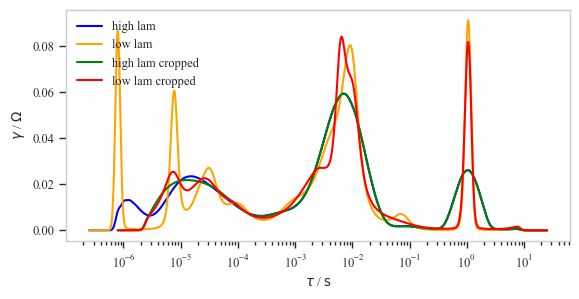

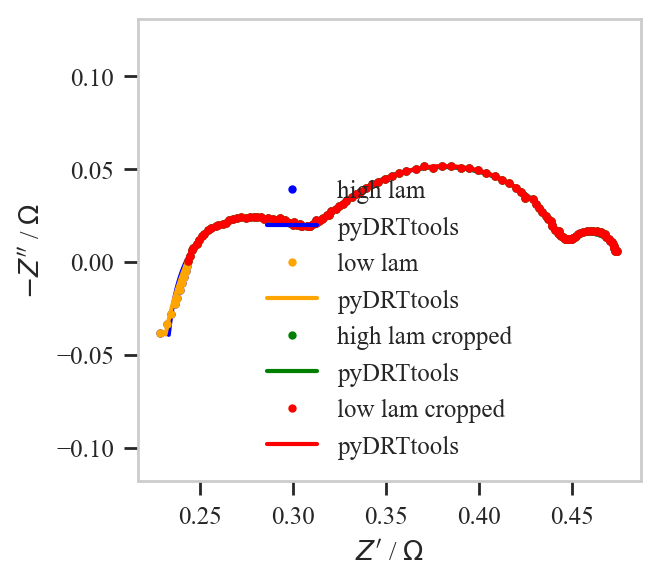

In [71]:
EISData_array = []
lambda_array = [1e-2, 1e-9, 1e-2, 1e-9]

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "high lam"
EISData_array.append(EISData_object)

ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "low lam"
EISData_array.append(EISData_object)

ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "high lam cropped"
EISData_object.trim_inductive()
# EISData_object.crop_frequency(0.001, 1e5)
EISData_array.append(EISData_object)

ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "low lam cropped"
EISData_object.trim_inductive()
EISData_array.append(EISData_object)

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    # EISData_object.crop_frequency(0.001, 2e5)
    pass


DRT_array = []
L_array = []
R_array = []
EIS_fitted_array = []

for i, EISData_object in enumerate(EISData_array):
    # Load measurement data into EIS_object
    pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
    # this includes tau definition of
    # # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
    # # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0])


    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda
    lambda_0 = lambda_array[i] # initial guess
    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "pyDRTtools")

    DRT_array.append(DRT_object_pyDRTtools)
    L_array.append(L_pyDRTtools)
    R_array.append(R_pyDRTtools)
    EIS_fitted_array.append(EISData_fitted_pyDRTtools)


color_array = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
drt_plot = DRTPlot(figsize=(6.5, 3), dpi=100) 

nyquist_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for i, DRT_object in enumerate(DRT_array): 
    drt_plot.add_plot(DRT_object, linestyle = "-", marker = "", color=color_array[i])
    nyquist_plot.add_plot(EISData_array[i], linestyle = "", marker = "o", markersize = 2, color=color_array[i])
    nyquist_plot.add_plot(EIS_fitted_array[i], linestyle = "-", marker = "", color = color_array[i])
    print(f"DRT for {EISData_array[i].label}:")
    print(f"R = {R_array[i]}")
    print(f"L = {L_array[i]}")

drt_plot.ax.legend()
nyquist_plot.ax.legend()
display(drt_plot.fig)
display(nyquist_plot.fig)